# Beyond GDP: Human Development and Capability Analysis

## Notebook 5 — Clustering

So far we grouped countries ourselves, using HDI levels. Here we let the computer
do it. We give it the data and it finds groups of countries that are similar to
each other on their own.

We use a method called KMeans. The steps are:
1. Prepare the data so all measures are on the same scale.
2. Decide how many groups to make (using the Elbow method and Silhouette score).
3. Make the groups and see which countries fall together.
4. Read what each group means.

## 1. Setup

We load the cleaned master dataset and the tools from scikit-learn that we need:
StandardScaler to put all measures on the same scale, and KMeans to make the groups.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from pathlib import Path

master_path = Path(r"D:\beyond-gdp-capability-analysis\data\processed\master_dataset.csv")
df = pd.read_csv(master_path)

sns.set_theme(style="whitegrid", palette="muted")

print("Shape:", df.shape)
df.head(3)

Shape: (130, 18)


,country,code,hdi,life_expectancy,expected_schooling,mean_schooling,gni_per_capita,happiness_score,social_support_contrib,freedom_contrib,generosity_contrib,corruption_contrib,gdp_per_capita,health_expenditure,unemployment,inflation,population,cpi_score
0,Iceland,ISL,0.972,82.691,18.85059,13.908926,69116.93736,7.525,1.617,0.819,0.258,0.182,82138.789297,8.705101,3.518,8.736303,385663.0,77
1,Norway,NOR,0.970,83.308,18.79285,13.117962,112710.02110,7.302,1.517,0.835,0.224,0.484,87497.217965,9.429255,3.574,5.517850,5519601.0,81
2,Switzerland,CHE,0.970,83.954,16.66753,13.949121,81948.90177,7.060,1.425,0.759,0.173,0.498,100623.549627,11.690961,4.043,2.135401,8888822.0,80


## 2. Choose features and scale them

We pick the measures that describe a country's development, then scale them.

Scaling is important here. Our numbers are on very different sizes (GDP is in tens
of thousands, HDI is between 0 and 1). Without scaling, the computer would treat the
big numbers as more important. Scaling puts every measure on the same footing so all
of them count equally.

We also avoid using two measures that say almost the same thing (for example GDP and
GNI are both income), to stop one idea from being counted twice.

In [4]:
features = ["hdi", "life_expectancy", "mean_schooling", "gdp_per_capita",
            "happiness_score", "health_expenditure", "cpi_score"]

X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features used:", features)
print("Scaled data shape:", X_scaled.shape)
print("Example, first country scaled values:")
print(np.round(X_scaled[0], 2))

Features used: ['hdi', 'life_expectancy', 'mean_schooling', 'gdp_per_capita', 'happiness_score', 'health_expenditure', 'cpi_score']
Scaled data shape: (130, 7)
Example, first country scaled values:
[1.38 1.18 1.35 2.46 1.68 0.63 1.78]


## 3. How many groups? (Elbow method)

KMeans needs us to choose the number of groups. Instead of guessing, we try 1 to 10
groups and measure how tightly the countries fit their group each time (a value
called inertia, lower is tighter).

As we add more groups, inertia keeps falling. But at some point the fall slows down
sharply, that bend looks like an elbow. The number of groups at the elbow is a good
choice, because adding more after that gives little extra benefit.

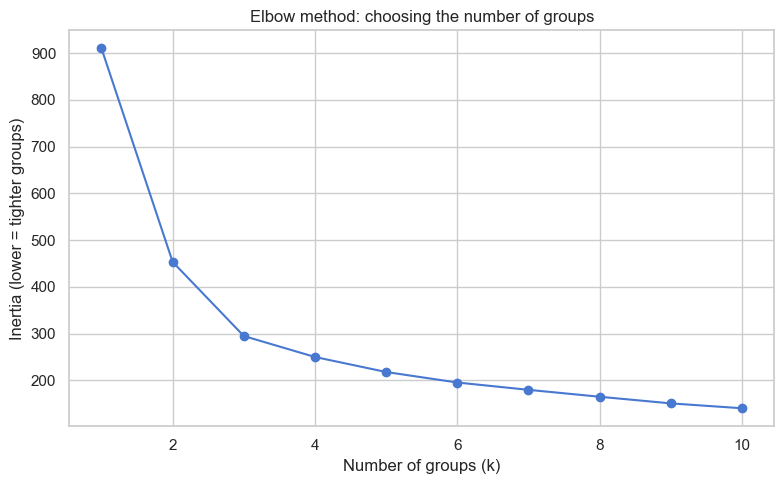

In [5]:
inertia = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker="o")
plt.title("Elbow method: choosing the number of groups")
plt.xlabel("Number of groups (k)")
plt.ylabel("Inertia (lower = tighter groups)")
plt.tight_layout()
plt.show()

## 4. Confirm the number with the Silhouette score

The elbow points to about 3 groups, but the elbow can be a little unclear. So we
check with a second method: the Silhouette score.

This score measures how well each country fits its own group compared to other
groups. It runs from -1 to +1, and higher is better. We try a few values of k and
pick the one with the best score.

In [6]:
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"Groups = {k}  ->  silhouette score = {round(score, 3)}")

Groups = 2  ->  silhouette score = 0.412
Groups = 3  ->  silhouette score = 0.383
Groups = 4  ->  silhouette score = 0.314
Groups = 5  ->  silhouette score = 0.309
Groups = 6  ->  silhouette score = 0.27


## 5. Build the final groups (k = 3)

Both methods point to a small number of groups. The silhouette score is highest at
2 (0.412) and close behind at 3 (0.383), and the elbow was at 3. We choose 3 groups.
The score at 3 is almost as good as at 2, the elbow supports it, and three groups
give a more useful picture (roughly higher, middle and lower development) than just
two. This is a balance of the score and how useful the result is.

In [7]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)

print("Countries in each cluster:")
print(df["cluster"].value_counts().sort_index())

Countries in each cluster:
cluster
0    38
1    34
2    58
Name: count, dtype: int64


## 6. What does each group mean?

The group numbers (0, 1, 2) are just labels with no meaning yet. To understand them,
we look at the average of each measure inside each group. The group with the highest
averages is the more developed one, and the lowest is the least developed.

In [8]:
summary = df.groupby("cluster")[["hdi", "gdp_per_capita", "happiness_score",
                                 "life_expectancy", "cpi_score"]].mean()
summary = summary.round(2)

print(summary.to_string())
print()
print("Number of countries per cluster:")
print(df["cluster"].value_counts().sort_index())

          hdi  gdp_per_capita  happiness_score  life_expectancy  cpi_score
cluster                                                                   
0        0.93        51630.48             6.75            81.74      68.55
1        0.55         1430.22             4.29            64.77      31.24
2        0.78         9294.23             5.61            74.78      36.03

Number of countries per cluster:
cluster
0    38
1    34
2    58
Name: count, dtype: int64


**What the clusters mean:**

The computer split the 130 countries into three groups on its own. Looking at the
averages, the groups are clearly:

- High development (cluster 0, 38 countries): HDI 0.93, GDP 51,630, happiness 6.75,
  life expectancy 82, clean-governance score 69. These are the richest, healthiest,
  happiest countries.
- Middle development (cluster 2, 58 countries): HDI 0.78, GDP 9,294, happiness 5.61.
  The largest group, sitting in the middle on every measure.
- Low development (cluster 1, 34 countries): HDI 0.55, GDP 1,430, happiness 4.29,
  life expectancy 65. The poorest group, lowest on every measure.

The interesting part is what moves together. In the high group, GDP is about 36
times the low group, but happiness only goes from 4.29 to 6.75, and the
clean-governance score from 31 to 69. So money separates the groups the most, while
happiness changes far less between them.

This matches everything we found earlier: development, income, happiness and
governance tend to rise together, but income gaps are far larger than happiness
gaps. Money is the biggest divider, not the only thing that matters.

## 7. See the groups on a chart

We plot GDP against HDI again, but now each country is colored by its group. This
shows the three groups visually and where they sit.

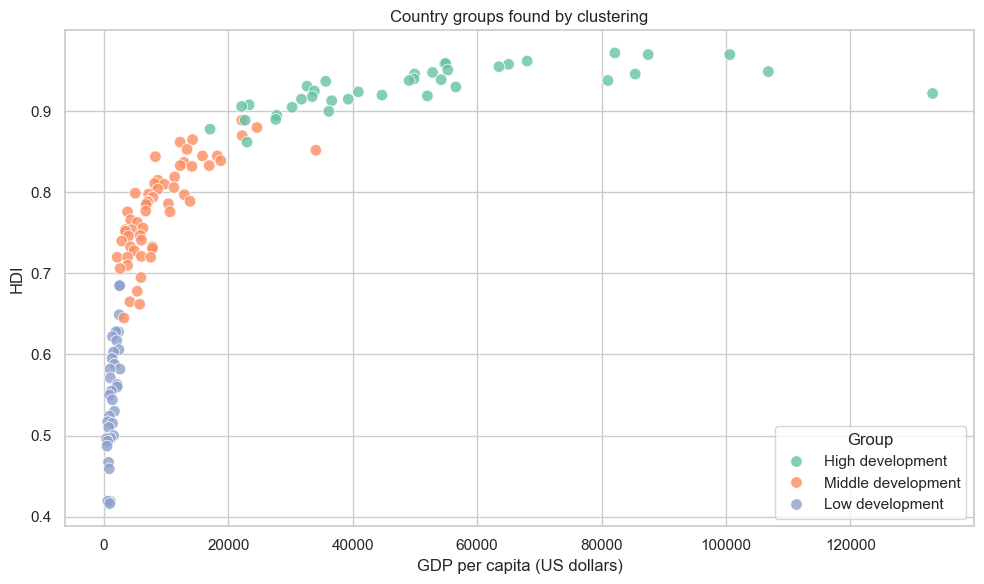

In [9]:
cluster_names = {0: "High development", 1: "Low development", 2: "Middle development"}
df["cluster_label"] = df["cluster"].map(cluster_names)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="gdp_per_capita", y="hdi",
                hue="cluster_label", palette="Set2", s=70, alpha=0.8)

plt.title("Country groups found by clustering")
plt.xlabel("GDP per capita (US dollars)")
plt.ylabel("HDI")
plt.legend(title="Group")
plt.tight_layout()
plt.show()

**What this chart shows:**

This is the same GDP vs HDI curve as before, but now each country is colored by the
group the computer found on its own.

The three groups fall neatly on different parts of the curve:
- Low development (blue) sits at the bottom-left, where both GDP and HDI are low.
- Middle development (orange) sits on the steep, bending part of the curve.
- High development (green) sits at the top-right, where both GDP and HDI are high.

The important point: we did not tell the computer about HDI levels or draw these
lines ourselves. It grouped the countries using all the measures together, and the
groups still line up perfectly with the GDP-HDI curve we saw earlier. That is a good
sign, two different methods (our charts and the clustering) point to the same
structure in the data.

It also shows the groups are not just about money. They differ on health, happiness
and governance too, all moving together, which is the project's main theme.